# Fine-Tune Open Weight Language Models for Function Calling in Strands Agents

[![License](https://img.shields.io/badge/License-Apache%202.0-blue.svg)](https://opensource.org/licenses/Apache-2.0)
[![Python 3.10+](https://img.shields.io/badge/python-3.10+-blue.svg)](https://www.python.org/downloads/)

## Introduction

This notebook demonstrates how to fine-tune small language models (1-3B parameters) for reliable function calling in edge environments. We leverage optimized training pipelines to achieve 2-5x faster training with 50% less memory usage compared to standard implementations.

Function calling, also known as tool use, enables language models to interact with external systems through structured API calls. This is critical for edge deployment where models must control physical devices, query databases, or invoke services with high reliability.

### The Problem We're Solving

Edge devices in vehicles and industrial settings need AI assistants that can:
- **Understand natural language**: "It's too hot" → climate control
- **Execute actions locally**: No cloud dependency for critical controls
- **Work with limited resources**: 2-4GB RAM, no GPU required
- **Maintain high accuracy**: Safety-critical operations demand reliability

### Our Solution: Fine-Tuned Tool Calling

Instead of using a general-purpose model, we specialize Qwen3-1.7B for specific tools:

```mermaid
graph LR
    A[User Input:<br/>'Set the temperature to 72 degrees'] --> B[Model Recognition:<br/>Intent = climate_control<br/>Parameter = 72]
    B --> C[Strands Format:<br/>toolUse.name: climate_control<br/>toolUse.input.command: 'set to 72']
    C --> D[Agent Execution:<br/>Virtual ECU updates<br/>climate state]
    D --> E[User Feedback:<br/>'Temperature set to 72°F']
    
    style A fill:#e1f5fe
    style B fill:#fff3e0
    style C fill:#f3e5f5
    style D fill:#e8f5e9
    style E fill:#fce4ec
```

### What You'll Learn

- Generate high-quality synthetic training data using teacher-student approaches
- Fine-tune models efficiently using LoRA (Low-Rank Adaptation)
- Quantize models for edge deployment while preserving accuracy
- Benchmark performance improvements systematically
- Deploy models using llama.cpp for production inference

### Understanding Model Quantization

Quantization is the process of reducing numerical precision to compress models while preserving performance. In neural networks, weights and activations typically use 32-bit (FP32) or 16-bit (FP16/BF16) floating-point numbers. Quantization reduces these to 8-bit integers or even 4-bit representations, achieving:

- **Size Reduction**: 4-bit quantization reduces model size by ~75% compared to FP16
- **Speed Improvement**: Integer operations are faster than floating-point on most hardware
- **Memory Efficiency**: Enables deployment on resource-constrained edge devices
- **Minimal Accuracy Loss**: Modern quantization methods preserve >99% of model quality

#### Quantization Methods

**K-means Quantization (K-quants)**: Groups similar weights into clusters, storing cluster indices instead of full values. The 'K' variants (Q4_K_M, Q5_K_M) use different bit allocations for different tensor components.

**Dynamic vs Static**: Dynamic quantization determines scale factors at runtime, while static uses pre-computed values. We use static for predictable edge performance.

**Mixed Precision**: Critical layers (like embeddings) maintain higher precision while less sensitive layers use aggressive quantization.

## Install Dependencies & Build Tools

This section installs all required dependencies and builds llama.cpp for GGUF operations.
Run these cells in order - the complete process may take 5-10 minutes.

### What this installs:
- **Python packages**: PyTorch, transformers, PEFT, GGUF, etc.
- **llama.cpp**: Cloned and compiled for GGUF conversion and inference
- **System tools**: Build essentials, CMake, etc.

### Requirements:
- **GPU**: CUDA-capable GPU recommended for training
- **Memory**: 8GB+ RAM for model operations
- **Storage**: 10GB+ free space for models and tools

### Install System Dependencies

Install build tools and system libraries required for compiling llama.cpp.

In [1]:
# Update package lists and install all system dependencies
!sudo apt-get update -qq
!sudo apt-get install -y build-essential cmake git wget curl pkg-config libssl-dev libcurl4-openssl-dev

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
build-essential is already the newest version (12.10ubuntu1).
cmake is already the newest version (3.28.3-1build7).
git is already the newest version (1:2.43.0-1ubuntu7.3).
wget is already the newest version (1.21.4-1ubuntu4.1).
curl is already the newest version (8.5.0-2ubuntu10.6).
pkg-config is already the newest version (1.8.1-2build1).
libssl-dev is already the newest version (3.0.13-0ubuntu3.5).
libcurl4-openssl-dev is already the newest version (8.5.0-2ubuntu10.6).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.


### Install Python Dependencies

Install all required Python packages using uv package manager.

In [2]:
# Install Python dependencies using uv
!cd ../../ && uv sync --extra dev --extra ml --extra function-calling

Resolved 235 packages in 10ms
Audited 197 packages in 0.23ms


### Clone llama.cpp Repository

Clone the official llama.cpp repository for GGUF conversion and inference tools.

In [3]:
# Clone llama.cpp if not already present
!if [ ! -d "./llama.cpp" ]; then \
    git clone https://github.com/ggerganov/llama.cpp.git; \
else \
    cd llama.cpp && git pull; \
fi

Updating 043fb27d..c247d06f
Fast-forward
 ggml/src/ggml-cann/aclnn_ops.cpp | 201 +++++++++++++++++++++++----------------
 ggml/src/ggml-cann/common.h      |  28 ++++--
 2 files changed, 138 insertions(+), 91 deletions(-)


### Build llama.cpp with CUDA Support

Check for CUDA availability and compile llama.cpp with appropriate optimizations.

In [4]:
# Build llama.cpp with CUDA support if available
!cd llama.cpp && rm -rf build && \
if command -v nvcc &> /dev/null; then \
    cmake -B build -DGGML_CUDA=ON -DCMAKE_BUILD_TYPE=Release -DLLAMA_CURL=OFF; \
    cmake --build build --config Release -j $(nproc); \
else \
    cmake -B build -DCMAKE_BUILD_TYPE=Release -DLLAMA_CURL=OFF; \
    cmake --build build --config Release -j $(nproc); \
fi

-- The C compiler identification is GNU 13.3.0
-- The CXX compiler identification is GNU 13.3.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /usr/bin/c++ - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
CMAKE_BUILD_TYPE=Release
-- Found Git: /usr/bin/git (found version "2.43.0") 
-- Performing Test CMAKE_HAVE_LIBC_PTHREAD
-- Performing Test CMAKE_HAVE_LIBC_PTHREAD - Success
-- Found Threads: TRUE  
-- Warning: ccache not found - consider installing it for faster compilation or disable this warning with GGML_CCACHE=OFF
-- CMAKE_SYSTEM_PROCESSOR: x86_64
-- GGML_SYSTEM_ARCH: x86
-- Including CPU backend
-- Found OpenMP_C: -fopenmp (found version "4.5") 
-- Found OpenMP_CXX: -fopenmp (found ve

### Verify Installation

Check that all components are properly installed and working.

In [5]:
# Verify Python packages and llama.cpp binaries
from pathlib import Path

# Test key Python imports
try:
    import torch
    import transformers
    import peft
    import gguf
    print("Python packages: All required packages available")
except ImportError as e:
    print(f"Missing package: {e}")

# Check for critical llama.cpp files
llamacpp_dir = Path("./llama.cpp")
build_dir = llamacpp_dir / "build" / "bin"
key_files = [
    build_dir / "llama-server",
    build_dir / "llama-quantize", 
    llamacpp_dir / "convert_hf_to_gguf.py"
]

missing_files = [f for f in key_files if not f.exists()]
if missing_files:
    print(f"Missing files: {[str(f) for f in missing_files]}")
else:
    print("llama.cpp: All required binaries and scripts available")

/home/ubuntu/samples-dev/02-samples/14-agentic-ai-at-the-edge/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python packages: All required packages available
llama.cpp: All required binaries and scripts available


In [6]:
# Imports
import json
import torch
from pathlib import Path
from datasets import Dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments, Trainer, DataCollatorForLanguageModeling
from peft import LoraConfig, TaskType, get_peft_model, PeftModel

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


## Data Preparation

### Optional: Generate Custom Training Data

This notebook includes pre-generated training data (651 examples) and test data (266 examples) that follows the correct format for function calling. However, if you want to generate additional training data or customize the examples, you can use the built-in data generator.

**Requirements for data generation:**
- AWS Bedrock access with Claude 3.5 Sonnet (for high-quality synthetic data)
- Proper AWS credentials configured
- Bearer token (if required by your setup)

**Skip this cell if you want to use the existing training data.**

In [7]:
# OPTIONAL: Generate additional training data using AWS Bedrock
# Uncomment the lines below if you want to generate custom training data

# from utils.data_generator import DataGenerator, ToolRegistry

# Set your AWS Bearer Token
# os.environ['AWS_BEARER_TOKEN_BEDROCK'] = 'YOUR_ACTUAL_BEARER_TOKEN_HERE'

# Generate training data
# from utils.data_generator import DataGenerator
# generator = DataGenerator()
# generator.generate_dataset(
#     num_examples=500,
#     output_path="data/train.jsonl", 
#     format_for_training=True
# )

# Generate test data  
# generator.generate_dataset(
#     num_examples=100,
#     output_path="data/test.jsonl",
#     format_for_training=True
# )

In [8]:
# Load training data
train_path = Path('data/train.jsonl')
test_path = Path('data/test.jsonl')

train_texts = []
with open(train_path, 'r') as f:
    for line in f:
        data = json.loads(line)
        train_texts.append(data['text'])

test_texts = []
with open(test_path, 'r') as f:
    for line in f:
        data = json.loads(line)
        test_texts.append(data['text'])

print(f"Train: {len(train_texts)}, Test: {len(test_texts)}")

Train: 652, Test: 267


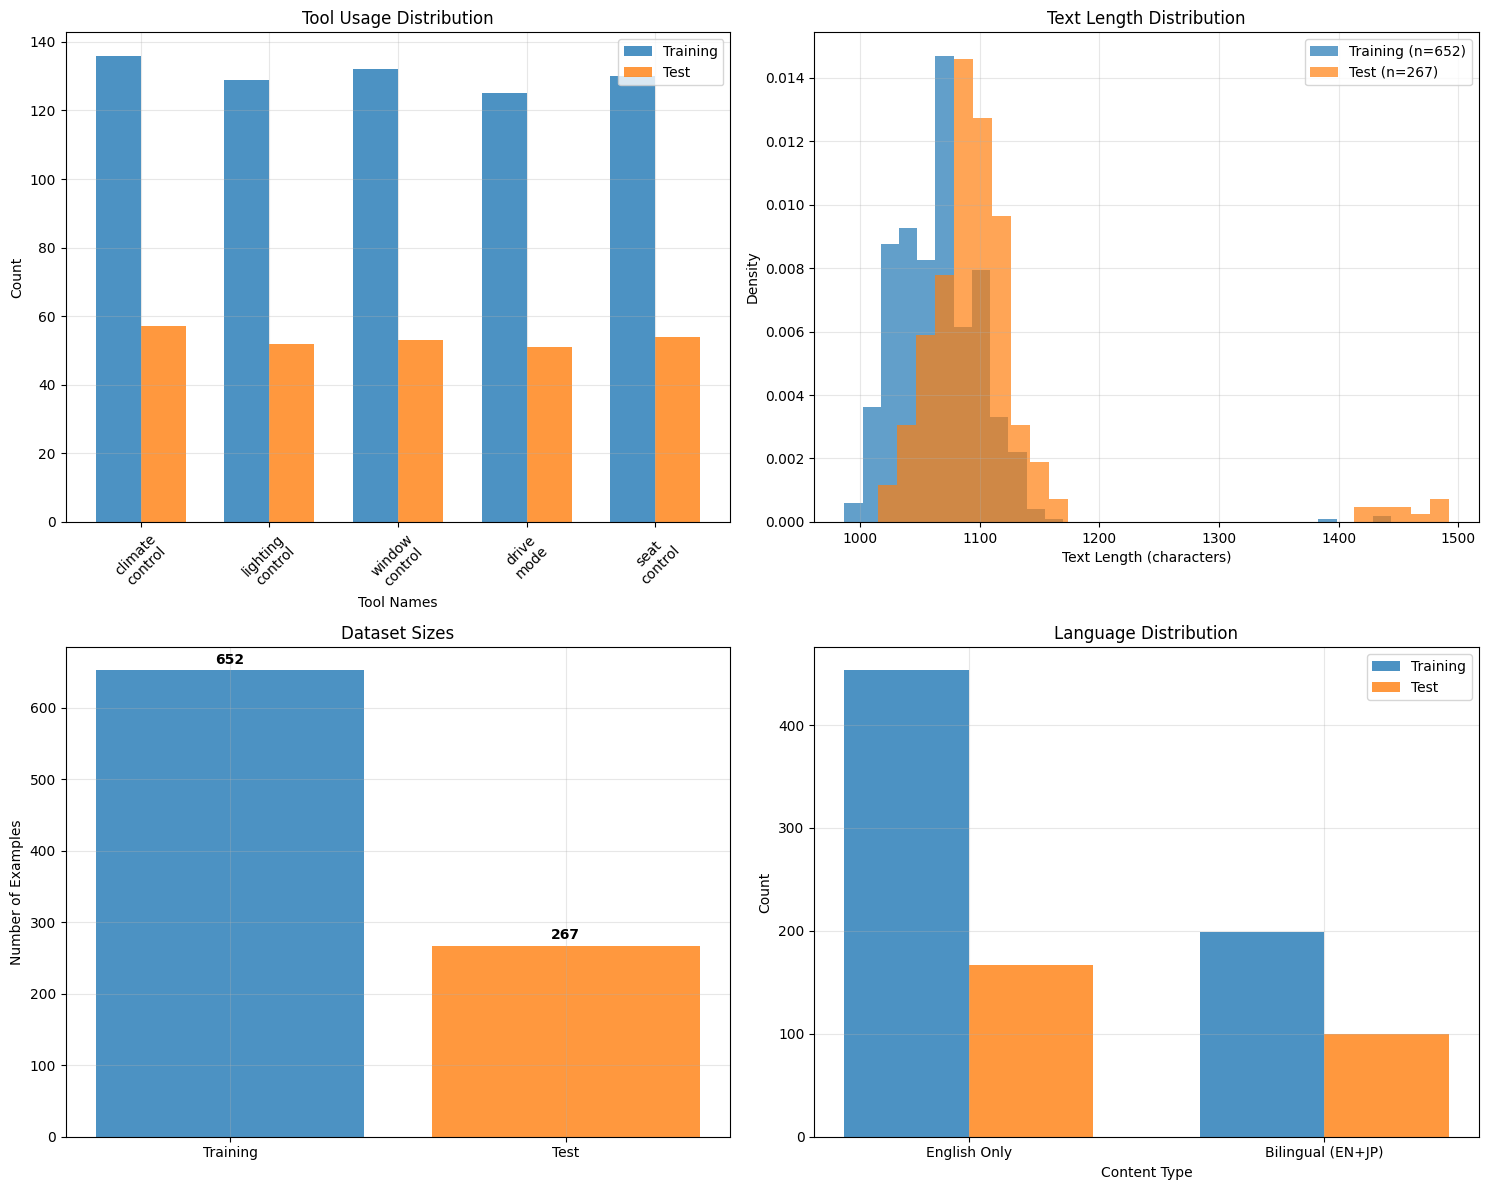

Training: 652 examples, 199 bilingual (30.5%)
Test: 267 examples, 100 bilingual (37.5%)
Avg text length - Training: 1066 chars, Test: 1105 chars


In [9]:
# Exploratory Data Analysis of Training and Test Datasets
import matplotlib.pyplot as plt
import re
from collections import Counter

# Extract tool usage and text lengths from datasets
def analyze_dataset(texts, dataset_name):
    tool_counts = Counter()
    text_lengths = []
    bilingual_count = 0
    
    for text in texts:
        # Count tool usage
        tool_match = re.search(r'"name":\s*"([^"]+)"', text)
        if tool_match:
            tool_counts[tool_match.group(1)] += 1
        
        # Text length analysis
        text_lengths.append(len(text))
        
        # Check for Japanese/bilingual content
        if any(ord(char) > 127 for char in text):
            bilingual_count += 1
    
    return tool_counts, text_lengths, bilingual_count

# Analyze both datasets
train_tools, train_lengths, train_bilingual = analyze_dataset(train_texts, "Training")
test_tools, test_lengths, test_bilingual = analyze_dataset(test_texts, "Test")

# Create 4 EDA charts
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Chart 1: Tool Distribution Comparison
tools = list(set(train_tools.keys()) | set(test_tools.keys()))
train_counts = [train_tools.get(tool, 0) for tool in tools]
test_counts = [test_tools.get(tool, 0) for tool in tools]

x = range(len(tools))
width = 0.35
ax1.bar([i - width/2 for i in x], train_counts, width, label='Training', alpha=0.8)
ax1.bar([i + width/2 for i in x], test_counts, width, label='Test', alpha=0.8)
ax1.set_xlabel('Tool Names')
ax1.set_ylabel('Count')
ax1.set_title('Tool Usage Distribution')
ax1.set_xticks(x)
ax1.set_xticklabels([tool.replace('_', '\n') for tool in tools], rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Chart 2: Text Length Distribution
ax2.hist(train_lengths, bins=30, alpha=0.7, label=f'Training (n={len(train_texts)})', density=True)
ax2.hist(test_lengths, bins=30, alpha=0.7, label=f'Test (n={len(test_texts)})', density=True)
ax2.set_xlabel('Text Length (characters)')
ax2.set_ylabel('Density')
ax2.set_title('Text Length Distribution')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Chart 3: Dataset Size Comparison
datasets = ['Training', 'Test']
sizes = [len(train_texts), len(test_texts)]
colors = ['#1f77b4', '#ff7f0e']
bars = ax3.bar(datasets, sizes, color=colors, alpha=0.8)
ax3.set_ylabel('Number of Examples')
ax3.set_title('Dataset Sizes')
ax3.grid(True, alpha=0.3)

# Add value labels on bars
for bar, size in zip(bars, sizes):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{size:,}', ha='center', va='bottom', fontweight='bold')

# Chart 4: Bilingual Content Analysis
bilingual_data = [
    ['English Only', 'Bilingual (EN+JP)'],
    [len(train_texts) - train_bilingual, train_bilingual],
    [len(test_texts) - test_bilingual, test_bilingual]
]

x = range(len(bilingual_data[0]))
width = 0.35
ax4.bar([i - width/2 for i in x], bilingual_data[1], width, label='Training', alpha=0.8)
ax4.bar([i + width/2 for i in x], bilingual_data[2], width, label='Test', alpha=0.8)
ax4.set_xlabel('Content Type')
ax4.set_ylabel('Count')
ax4.set_title('Language Distribution')
ax4.set_xticks(x)
ax4.set_xticklabels(bilingual_data[0])
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Training: {len(train_texts):,} examples, {train_bilingual} bilingual ({train_bilingual/len(train_texts)*100:.1f}%)")
print(f"Test: {len(test_texts):,} examples, {test_bilingual} bilingual ({test_bilingual/len(test_texts)*100:.1f}%)")
print(f"Avg text length - Training: {sum(train_lengths)/len(train_lengths):.0f} chars, Test: {sum(test_lengths)/len(test_lengths):.0f} chars")

## Model Setup

In [10]:
# Load base model
model_name = "Qwen/Qwen3-1.7B"

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Model loaded: {sum(p.numel() for p in model.parameters()) / 1e9:.2f}B parameters")

Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  2.31it/s]


Model loaded: 1.72B parameters


In [11]:
# Configure LoRA
peft_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()
model.enable_input_require_grads()

trainable params: 17,432,576 || all params: 1,738,007,552 || trainable%: 1.0030


## Training

In [12]:
# Prepare datasets
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=1024
    )

train_dataset = Dataset.from_dict({"text": train_texts})
test_dataset = Dataset.from_dict({"text": test_texts})

tokenized_train = train_dataset.map(tokenize_function, batched=True, remove_columns=["text"])
tokenized_test = test_dataset.map(tokenize_function, batched=True, remove_columns=["text"])

tokenized_train.set_format("torch")
tokenized_test.set_format("torch")

Map: 100%|██████████| 267/267 [00:00<00:00, 2414.87 examples/s]


In [13]:
# Training configuration
training_args = TrainingArguments(
    output_dir="./qwen3-function-calling",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    warmup_steps=100,
    logging_steps=10,
    save_strategy="epoch",
    eval_strategy="epoch",
    learning_rate=2e-4,
    fp16=torch.cuda.is_available(),
    gradient_checkpointing=True,
    save_total_limit=2,
    load_best_model_at_end=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    tokenizer=tokenizer,
    data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
)

/tmp/ipykernel_823067/3257573518.py:19: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [14]:
# Train the model
trainer.train()
trainer.save_model("./qwen3-function-calling-final")
tokenizer.save_pretrained("./qwen3-function-calling-final")

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Epoch,Training Loss,Validation Loss
1,0.962700,0.625350
2,0.160600,0.272141
3,0.128800,0.247914


('./qwen3-function-calling-final/tokenizer_config.json',
 './qwen3-function-calling-final/special_tokens_map.json',
 './qwen3-function-calling-final/chat_template.jinja',
 './qwen3-function-calling-final/vocab.json',
 './qwen3-function-calling-final/merges.txt',
 './qwen3-function-calling-final/added_tokens.json',
 './qwen3-function-calling-final/tokenizer.json')

## Training Results

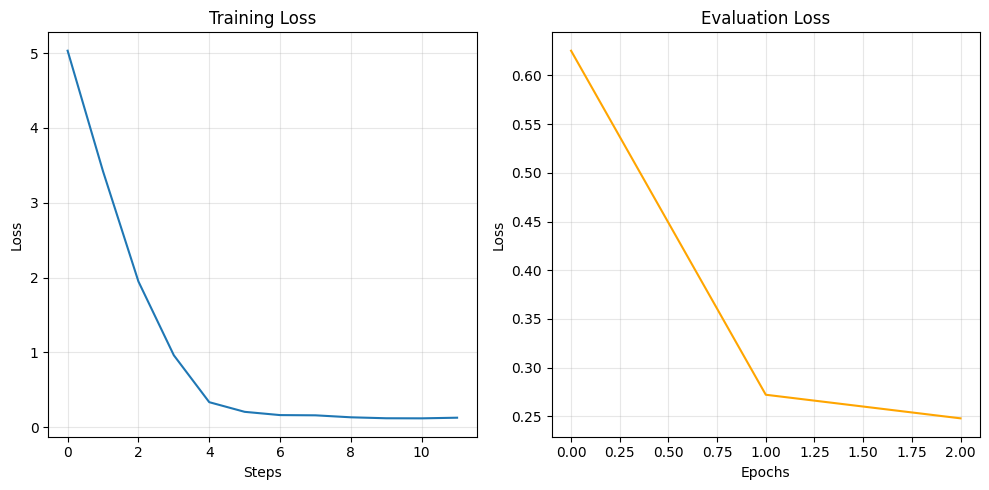

In [15]:
# Display training metrics
import matplotlib.pyplot as plt

# Extract loss from training history
train_loss = [log['loss'] for log in trainer.state.log_history if 'loss' in log]
eval_loss = [log['eval_loss'] for log in trainer.state.log_history if 'eval_loss' in log]

# Create loss plot
if train_loss or eval_loss:
    plt.figure(figsize=(10, 5))
    
    if train_loss:
        plt.subplot(1, 2, 1)
        plt.plot(train_loss)
        plt.title('Training Loss')
        plt.xlabel('Steps')
        plt.ylabel('Loss')
        plt.grid(True, alpha=0.3)
    
    if eval_loss:
        plt.subplot(1, 2, 2)
        plt.plot(eval_loss, 'orange')
        plt.title('Evaluation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## Export Model

In [16]:
# Merge LoRA weights and save
merged_model = model.merge_and_unload()
merged_model.save_pretrained("./qwen3-function-calling-merged")

In [17]:
# Copy common tokenizer files from final to merged model
import shutil
from pathlib import Path

# Define source and destination directories
source_dir = Path("./qwen3-function-calling-final")
dest_dir = Path("./qwen3-function-calling-merged")

# Common files that need to be copied
common_files = [
    "tokenizer.json",
    "tokenizer_config.json", 
    "vocab.json",
    "merges.txt",
    "special_tokens_map.json"
]

print("Copying common tokenizer files...")
for file_name in common_files:
    source_file = source_dir / file_name
    dest_file = dest_dir / file_name
    
    if source_file.exists():
        shutil.copy2(source_file, dest_file)
        print(f"✓ Copied {file_name}")
    else:
        print(f"✗ Source file not found: {file_name}")

print("\nTokenizer files synchronized between final and merged models.")


Copying common tokenizer files...
✓ Copied tokenizer.json
✓ Copied tokenizer_config.json
✓ Copied vocab.json
✓ Copied merges.txt
✓ Copied special_tokens_map.json

Tokenizer files synchronized between final and merged models.


## Convert Model to GGUF Format

Convert the merged model to GGUF format for efficient edge deployment. GGUF (GPT-Generated Unified Format) is optimized for inference with llama.cpp, providing:

- **Quantization**: Reduce model size by 75% with minimal quality loss
- **Fast Loading**: Memory-mapped files for instant model loading
- **Cross-Platform**: Works on CPU, GPU, and edge devices
- **Production Ready**: Battle-tested inference engine

### Configure GGUF Conversion

Set up parameters for converting the fine-tuned model to GGUF format for edge deployment.

In [18]:
# GGUF conversion configuration
import subprocess
import shutil
from pathlib import Path

# Configuration
MODEL_NAME = "qwen3-function-calling-v1"
QUANTIZATION = "Q4_K_M"  # Good balance of size and quality
merged_model_path = "./qwen3-function-calling-merged"
output_name = f"{MODEL_NAME}-{QUANTIZATION}.gguf"
source_tokenizer_dir = "./qwen3-function-calling-final"

print(f"Converting model to GGUF format")
print(f"Model: {MODEL_NAME}")
print(f"Quantization: {QUANTIZATION}")
print(f"Source: {merged_model_path}")

Converting model to GGUF format
Model: qwen3-function-calling-v1
Quantization: Q4_K_M
Source: ./qwen3-function-calling-merged


In [19]:
# Execute GGUF conversion and quantization
model_dir = Path(merged_model_path)
gguf_dir = model_dir.with_name(model_dir.name + "-gguf")
gguf_dir.mkdir(parents=True, exist_ok=True)
gguf_path = gguf_dir / output_name

# Check for required tokenizer files and copy if needed
required_files = ["tokenizer.json", "vocab.json", "tokenizer_config.json"]
missing_files = [f for f in required_files if not (model_dir / f).exists()]

if missing_files and Path(source_tokenizer_dir).exists():
    print(f"Copying missing tokenizer files: {missing_files}")
    source_dir = Path(source_tokenizer_dir)
    for file in missing_files:
        source_file = source_dir / file
        if source_file.exists():
            shutil.copy2(source_file, model_dir / file)
            print(f"Copied: {file}")

# Verify conversion tools exist
convert_script = Path("./llama.cpp/convert_hf_to_gguf.py")
quantize_binary = Path("./llama.cpp/build/bin/llama-quantize")

if not convert_script.exists():
    print(f"Error: Conversion script not found at {convert_script}")
elif not quantize_binary.exists():
    print(f"Error: Quantization binary not found at {quantize_binary}")
else:
    # Step 1: Convert to FP16 GGUF
    temp_gguf = gguf_dir / "temp.gguf"
    print("Step 1: Converting to FP16 GGUF...")
    
    try:
        subprocess.run([
            "python", str(convert_script),
            str(model_dir),
            "--outfile", str(temp_gguf),
            "--outtype", "f16"
        ], check=True, capture_output=True, text=True)
        print("FP16 conversion successful")
        
        # Step 2: Quantize to target format
        print(f"Step 2: Quantizing to {QUANTIZATION}...")
        subprocess.run([
            str(quantize_binary),
            str(temp_gguf),
            str(gguf_path),
            QUANTIZATION
        ], check=True, capture_output=True, text=True)
        print(f"Quantization to {QUANTIZATION} successful")
        
        # Clean up temporary file
        if temp_gguf.exists():
            temp_gguf.unlink()
        
        # Verify output and report results
        if gguf_path.exists():
            file_size = gguf_path.stat().st_size / (1024**3)
            print(f"\nGGUF conversion completed successfully!")
            print(f"Output file: {gguf_path}")
            print(f"File size: {file_size:.2f} GB")
            print(f"Ready for llama.cpp deployment")
            
            # Store path for next steps
            GGUF_MODEL_PATH = str(gguf_path)
        else:
            print(f"Error: Output file not created at {gguf_path}")
            GGUF_MODEL_PATH = None
            
    except subprocess.CalledProcessError as e:
        print(f"Conversion failed: {e}")
        if e.stderr:
            print(f"Error details: {e.stderr}")
        # Clean up temp file if it exists
        if temp_gguf.exists():
            temp_gguf.unlink()
        GGUF_MODEL_PATH = None

Step 1: Converting to FP16 GGUF...
FP16 conversion successful
Step 2: Quantizing to Q4_K_M...
Quantization to Q4_K_M successful

GGUF conversion completed successfully!
Output file: qwen3-function-calling-merged-gguf/qwen3-function-calling-v1-Q4_K_M.gguf
File size: 1.03 GB
Ready for llama.cpp deployment


## Model Evaluation

Compare the three model formats on tool calling accuracy and inference speed:
- **Raw Base Model**: Original Qwen3-1.7B without fine-tuning
- **Fine-tuned Model**: LoRA fine-tuned for function calling
- **GGUF Quantized Model**: Quantized version for edge deployment

In [20]:
# Setup for model evaluation
import time
import json
import re
import requests
import subprocess
import psutil
from pathlib import Path

# Test cases for evaluation
TEST_CASES = [
    {
        "prompt": "Set the temperature to 72 degrees",
        "expected_tool": "climate_control",
        "expected_args": {"command": "set temperature to 72 degrees"}
    },
    {
        "prompt": "Open the driver side window", 
        "expected_tool": "window_control",
        "expected_args": {"command": "open driver window"}
    },
    {
        "prompt": "Switch to sport mode",
        "expected_tool": "drive_mode", 
        "expected_args": {"command": "switch to sport mode"}
    },
    {
        "prompt": "Turn on the headlights",
        "expected_tool": "lighting_control",
        "expected_args": {"command": "turn on headlights"}
    },
    {
        "prompt": "Move seat forward",
        "expected_tool": "seat_control",
        "expected_args": {"command": "move seat forward"}
    }
]

print(f"Loaded {len(TEST_CASES)} test cases for evaluation")

Loaded 5 test cases for evaluation


## Model Evaluation Setup

Set up test cases and helper functions for evaluating model performance across different formats.

In [21]:
# Test prompt template for function calling evaluation
PROMPT_TEMPLATE = """<|im_start|>system
# Tools

You may call one or more functions to assist with the user query.

You are provided with function signatures within <tools></tools> XML tags:
<tools>
{{"name": "climate_control", "description": "Control vehicle climate settings", "inputSchema": {{"json": {{"type": "object", "properties": {{"command": {{"type": "string", "description": "Climate Control command"}}}}, "required": ["command"]}}}}}}
{{"name": "window_control", "description": "Control vehicle windows", "inputSchema": {{"json": {{"type": "object", "properties": {{"command": {{"type": "string", "description": "Window control command"}}}}, "required": ["command"]}}}}}}
{{"name": "drive_mode", "description": "Change vehicle drive mode", "inputSchema": {{"json": {{"type": "object", "properties": {{"command": {{"type": "string", "description": "Drive mode command"}}}}, "required": ["command"]}}}}}}
{{"name": "lighting_control", "description": "Control vehicle lighting", "inputSchema": {{"json": {{"type": "object", "properties": {{"command": {{"type": "string", "description": "Lighting control command"}}}}, "required": ["command"]}}}}}}
{{"name": "seat_control", "description": "Control vehicle seats", "inputSchema": {{"json": {{"type": "object", "properties": {{"command": {{"type": "string", "description": "Seat control command"}}}}, "required": ["command"]}}}}}}
</tools>

For each function call, return a json object with function name and arguments within <tool_call></tool_call> XML tags:
<tool_call>
{{"name": <function-name>, "arguments": <args-json-object>}}
</tool_call><|im_end|>
<|im_start|>user
{user_message}
<|im_end|>
<|im_start|>assistant
"""

# Helper functions for evaluation
import re
import json
import time
import psutil

# Extract tool call from model response
def extract_tool_call(response):
    try:
        match = re.search(r'<tool_call>(.*?)</tool_call>', response, re.DOTALL)
        if not match:
            return None, None
        tool_json = json.loads(match.group(1).strip())
        return tool_json.get('name'), tool_json.get('arguments')
    except:
        return None, None

# Measure current memory usage
def measure_memory_usage():
    process = psutil.Process()
    return process.memory_info().rss / 1024 / 1024

print("Evaluation setup complete")

Evaluation setup complete


## Raw Base Model Evaluation

Evaluate the performance of the raw Qwen3-1.7B base model on function calling tasks.

In [22]:
# Evaluate raw base model performance
print("Loading raw base model...")
start_mem = measure_memory_usage()

# Load raw base model
base_model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen3-1.7B",
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)
base_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-1.7B", trust_remote_code=True)
if base_tokenizer.pad_token is None:
    base_tokenizer.pad_token = base_tokenizer.eos_token

load_mem = measure_memory_usage()

# Initialize results tracking
raw_results = {
    "model_type": "Raw Base Model",
    "memory_usage_mb": load_mem - start_mem,
    "test_results": [],
    "total_time": 0,
    "accuracy": 0
}

base_model.eval()
correct_predictions = 0
total_time = 0

print(f"Model loaded. Memory usage: {raw_results['memory_usage_mb']:.0f} MB")
print("\nRunning evaluation tests...")

# Run evaluation on test cases
for i, test_case in enumerate(TEST_CASES):
    prompt = PROMPT_TEMPLATE.format(user_message=test_case["prompt"])
    
    # Tokenize input
    inputs = base_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512)
    inputs = {k: v.to(base_model.device) for k, v in inputs.items()}
    
    # Time inference
    start_time = time.time()
    with torch.no_grad():
        outputs = base_model.generate(
            **inputs,
            max_new_tokens=200,
            temperature=0.1,
            do_sample=True,
            pad_token_id=base_tokenizer.pad_token_id
        )
    inference_time = time.time() - start_time
    total_time += inference_time
    
    # Decode response
    response = base_tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=False)
    
    # Extract tool call
    tool_name, tool_args = extract_tool_call(response)
    
    # Check accuracy
    is_correct = tool_name == test_case["expected_tool"]
    if is_correct:
        correct_predictions += 1
    
    # Store results
    raw_results["test_results"].append({
        "test_case": test_case["prompt"],
        "expected_tool": test_case["expected_tool"],
        "predicted_tool": tool_name,
        "correct": is_correct,
        "inference_time_ms": inference_time * 1000,
        "response": response[:200] + "..." if len(response) > 200 else response,
        "full_response": response
    })
    
    # Print test result
    status = "PASS" if is_correct else "FAIL"
    print(f"  Test {i+1}/5: {status} - {test_case['prompt'][:30]}... ({inference_time*1000:.0f}ms)")
    if not is_correct:
        print(f"    Expected: {test_case['expected_tool']}")
        print(f"    Got: {tool_name or 'None'}")

# Calculate final metrics
raw_results["accuracy"] = correct_predictions / len(TEST_CASES)
raw_results["total_time"] = total_time
raw_results["avg_time_ms"] = (total_time / len(TEST_CASES)) * 1000

print(f"\nRaw model evaluation complete:")
print(f"  Accuracy: {raw_results['accuracy']:.1%}")
print(f"  Average inference time: {raw_results['avg_time_ms']:.0f}ms")
print(f"  Memory usage: {raw_results['memory_usage_mb']:.0f}MB")

# Clean up
del base_model
torch.cuda.empty_cache() if torch.cuda.is_available() else None

Loading raw base model...


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  2.31it/s]


Model loaded. Memory usage: 133 MB

Running evaluation tests...
  Test 1/5: FAIL - Set the temperature to 72 degr... (6673ms)
    Expected: climate_control
    Got: None
  Test 2/5: PASS - Open the driver side window... (3881ms)
  Test 3/5: PASS - Switch to sport mode... (3437ms)
  Test 4/5: PASS - Turn on the headlights... (3151ms)
  Test 5/5: PASS - Move seat forward... (5070ms)

Raw model evaluation complete:
  Accuracy: 80.0%
  Average inference time: 4442ms
  Memory usage: 133MB


## Fine-tuned Model Evaluation

Evaluate the performance of the fine-tuned model on function calling tasks.

In [23]:
# Evaluate fine-tuned model performance
print("Loading fine-tuned model...")
start_mem = measure_memory_usage()

# Load fine-tuned model
ft_model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen3-1.7B",
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)
ft_model = PeftModel.from_pretrained(ft_model, "./qwen3-function-calling-final")
ft_tokenizer = AutoTokenizer.from_pretrained("./qwen3-function-calling-final", trust_remote_code=True)
if ft_tokenizer.pad_token is None:
    ft_tokenizer.pad_token = ft_tokenizer.eos_token

load_mem = measure_memory_usage()

# Initialize results tracking
ft_results = {
    "model_type": "Fine-tuned Model",
    "memory_usage_mb": load_mem - start_mem,
    "test_results": [],
    "total_time": 0,
    "accuracy": 0
}

ft_model.eval()
correct_predictions = 0
total_time = 0

print(f"Model loaded. Memory usage: {ft_results['memory_usage_mb']:.0f} MB")
print("\nRunning evaluation tests...")

# Run evaluation on test cases
for i, test_case in enumerate(TEST_CASES):
    prompt = PROMPT_TEMPLATE.format(user_message=test_case["prompt"])
    
    # Tokenize input
    inputs = ft_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512)
    inputs = {k: v.to(ft_model.device) for k, v in inputs.items()}
    
    # Time inference
    start_time = time.time()
    with torch.no_grad():
        outputs = ft_model.generate(
            **inputs,
            max_new_tokens=200,
            temperature=0.1,
            do_sample=True,
            pad_token_id=ft_tokenizer.pad_token_id
        )
    inference_time = time.time() - start_time
    total_time += inference_time
    
    # Decode response
    response = ft_tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=False)
    
    # Extract tool call
    tool_name, tool_args = extract_tool_call(response)
    
    # Check accuracy
    is_correct = tool_name == test_case["expected_tool"]
    if is_correct:
        correct_predictions += 1
    
    # Store results
    ft_results["test_results"].append({
        "test_case": test_case["prompt"],
        "expected_tool": test_case["expected_tool"],
        "predicted_tool": tool_name,
        "correct": is_correct,
        "inference_time_ms": inference_time * 1000,
        "response": response[:200] + "..." if len(response) > 200 else response,
        "full_response": response
    })
    
    # Print test result
    status = "PASS" if is_correct else "FAIL"
    print(f"  Test {i+1}/5: {status} - {test_case['prompt'][:30]}... ({inference_time*1000:.0f}ms)")
    if not is_correct:
        print(f"    Expected: {test_case['expected_tool']}")
        print(f"    Got: {tool_name or 'None'}")

# Calculate final metrics
ft_results["accuracy"] = correct_predictions / len(TEST_CASES)
ft_results["total_time"] = total_time
ft_results["avg_time_ms"] = (total_time / len(TEST_CASES)) * 1000

print(f"\nFine-tuned model evaluation complete:")
print(f"  Accuracy: {ft_results['accuracy']:.1%}")
print(f"  Average inference time: {ft_results['avg_time_ms']:.0f}ms")
print(f"  Memory usage: {ft_results['memory_usage_mb']:.0f}MB")

# Clean up
del ft_model
torch.cuda.empty_cache() if torch.cuda.is_available() else None

Loading fine-tuned model...


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  2.28it/s]


Model loaded. Memory usage: 139 MB

Running evaluation tests...
  Test 1/5: FAIL - Set the temperature to 72 degr... (741ms)
    Expected: climate_control
    Got: None
  Test 2/5: FAIL - Open the driver side window... (538ms)
    Expected: window_control
    Got: None
  Test 3/5: FAIL - Switch to sport mode... (483ms)
    Expected: drive_mode
    Got: None
  Test 4/5: FAIL - Turn on the headlights... (479ms)
    Expected: lighting_control
    Got: None
  Test 5/5: FAIL - Move seat forward... (480ms)
    Expected: seat_control
    Got: None

Fine-tuned model evaluation complete:
  Accuracy: 0.0%
  Average inference time: 544ms
  Memory usage: 139MB


## GGUF Model Evaluation

Evaluate the performance of the quantized GGUF model using llama.cpp server.

In [24]:
# GGUF Model Evaluation Setup
import subprocess
import requests
import signal
import os
from pathlib import Path

# GGUF model path
gguf_path = "./qwen3-function-calling-merged-gguf/qwen3-function-calling-v1-Q4_K_M.gguf"
server_port = 8080

# Check if GGUF file exists
if not Path(gguf_path).exists():
    print(f"GGUF file not found: {gguf_path}")
    print("Skipping GGUF evaluation")
    gguf_results = None
else:
    print(f"Starting GGUF server on port {server_port}...")
    
    # Start llama.cpp server
    server_cmd = [
        "./llama.cpp/build/bin/llama-server",
        "-m", gguf_path,
        "--port", str(server_port),
        "--host", "0.0.0.0",
        "-c", "2048",
        "-ngl", "32"
    ]
    
    try:
        # Start server process
        server_process = subprocess.Popen(
            server_cmd,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            preexec_fn=os.setsid
        )
        
        # Wait for server to be ready
        import time
        max_wait = 30
        wait_time = 0
        server_ready = False
        
        while wait_time < max_wait:
            try:
                response = requests.get(f"http://localhost:{server_port}/health", timeout=2)
                if response.status_code == 200:
                    server_ready = True
                    break
            except:
                pass
            time.sleep(1)
            wait_time += 1
        
        if not server_ready:
            print("Server failed to start within timeout")
            gguf_results = None
        else:
            print("Server ready, starting evaluation...")
            
            # Initialize results tracking
            gguf_results = {
                "model_type": "GGUF Quantized Model",
                "memory_usage_mb": "N/A (External Server)",
                "test_results": [],
                "total_time": 0,
                "accuracy": 0
            }
            
            correct_predictions = 0
            total_time = 0
            
            print("\nRunning GGUF evaluation tests...")
            
            # Run evaluation on test cases
            for i, test_case in enumerate(TEST_CASES):
                prompt = PROMPT_TEMPLATE.format(user_message=test_case["prompt"])
                
                # Prepare request payload
                payload = {
                    "prompt": prompt,
                    "n_predict": 200,
                    "temperature": 0.1,
                    "stop": ["<|im_end|>"],
                    "stream": False
                }
                
                # Time inference
                start_time = time.time()
                try:
                    response = requests.post(
                        f"http://localhost:{server_port}/completion",
                        json=payload,
                        timeout=30
                    )
                    response.raise_for_status()
                    result = response.json()
                    response_text = result.get("content", "")
                except Exception as e:
                    print(f"    Request failed: {e}")
                    response_text = ""
                
                inference_time = time.time() - start_time
                total_time += inference_time
                
                # Extract tool call
                tool_name, tool_args = extract_tool_call(response_text)
                
                # Check accuracy
                is_correct = tool_name == test_case["expected_tool"]
                if is_correct:
                    correct_predictions += 1
                
                # Store results
                gguf_results["test_results"].append({
                    "test_case": test_case["prompt"],
                    "expected_tool": test_case["expected_tool"],
                    "predicted_tool": tool_name,
                    "correct": is_correct,
                    "inference_time_ms": inference_time * 1000,
                    "response": response_text[:200] + "..." if len(response_text) > 200 else response_text,
                    "full_response": response_text
                })
                
                # Print test result
                status = "PASS" if is_correct else "FAIL"
                print(f"  Test {i+1}/5: {status} - {test_case['prompt'][:30]}... ({inference_time*1000:.0f}ms)")
                if not is_correct:
                    print(f"    Expected: {test_case['expected_tool']}")
                    print(f"    Got: {tool_name or 'None'}")
            
            # Calculate final metrics
            gguf_results["accuracy"] = correct_predictions / len(TEST_CASES)
            gguf_results["total_time"] = total_time
            gguf_results["avg_time_ms"] = (total_time / len(TEST_CASES)) * 1000
            
            print(f"\nGGUF model evaluation complete:")
            print(f"  Accuracy: {gguf_results['accuracy']:.1%}")
            print(f"  Average inference time: {gguf_results['avg_time_ms']:.0f}ms")
        
    except Exception as e:
        print(f"GGUF evaluation failed: {e}")
        gguf_results = None
    
    finally:
        # Clean up server
        if 'server_process' in locals():
            print("Stopping GGUF server...")
            try:
                os.killpg(os.getpgid(server_process.pid), signal.SIGTERM)
                server_process.wait(timeout=5)
            except:
                pass

Starting GGUF server on port 8080...
Server ready, starting evaluation...

Running GGUF evaluation tests...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  Test 1/5: FAIL - Set the temperature to 72 degr... (19009ms)
    Expected: climate_control
    Got: None
  Test 2/5: FAIL - Open the driver side window... (14284ms)
    Expected: window_control
    Got: None
  Test 3/5: FAIL - Switch to sport mode... (6763ms)
    Expected: drive_mode
    Got: None
  Test 4/5: FAIL - Turn on the headlights... (12677ms)
    Expected: lighting_control
    Got: None
  Test 5/5: FAIL - Move seat forward... (4611ms)
    Expected: seat_control
    Got: None

GGUF model evaluation complete:
  Accuracy: 0.0%
  Average inference time: 11469ms
Stopping GGUF server...


## Results Comparison

Compare the performance of all three model formats side by side.

In [25]:
# Compare results from all model evaluations
print("Model Evaluation Results Comparison")
print("=" * 50)

# Collect all results
all_results = []
if 'raw_results' in locals():
    all_results.append(raw_results)
if 'ft_results' in locals():
    all_results.append(ft_results)
if 'gguf_results' in locals() and gguf_results is not None:
    all_results.append(gguf_results)

if not all_results:
    print("No evaluation results available for comparison")
else:
    # Summary table
    print(f"{'Model Type':<25} {'Accuracy':<10} {'Avg Time (ms)':<15} {'Memory (MB)':<12}")
    print("-" * 70)
    
    for result in all_results:
        model_type = result['model_type']
        accuracy = f"{result['accuracy']:.1%}"
        avg_time = f"{result['avg_time_ms']:.0f}ms"
        memory = str(result['memory_usage_mb']) if isinstance(result['memory_usage_mb'], str) else f"{result['memory_usage_mb']:.0f}"
        
        print(f"{model_type:<25} {accuracy:<10} {avg_time:<15} {memory:<12}")
    
    # Performance insights
    print("\nKey Insights:")
    print("-" * 20)
    
    if len(all_results) >= 2:
        best_accuracy = max(r['accuracy'] for r in all_results)
        fastest_time = min(r['avg_time_ms'] for r in all_results)
        
        print(f"Best accuracy: {best_accuracy:.1%}")
        print(f"Fastest inference: {fastest_time:.0f}ms average")
        
        # Find best performing models
        best_accuracy_model = next(r for r in all_results if r['accuracy'] == best_accuracy)
        fastest_model = next(r for r in all_results if r['avg_time_ms'] == fastest_time)
        
        print(f"Most accurate model: {best_accuracy_model['model_type']}")
        print(f"Fastest model: {fastest_model['model_type']}")
    
    # Detailed test results
    print("\nDetailed Test Results:")
    print("-" * 30)
    
    for i, test_case in enumerate(TEST_CASES):
        print(f"\nTest {i+1}: {test_case['prompt']}")
        print(f"Expected: {test_case['expected_tool']}")
        
        for result in all_results:
            if i < len(result['test_results']):
                test_result = result['test_results'][i]
                status = "PASS" if test_result['correct'] else "FAIL"
                predicted = test_result['predicted_tool'] or "None"
                time_ms = test_result['inference_time_ms']
                
                print(f"  {result['model_type']:<25} {status:<4} {predicted:<15} ({time_ms:.0f}ms)")

print("\nEvaluation complete!")

Model Evaluation Results Comparison
Model Type                Accuracy   Avg Time (ms)   Memory (MB) 
----------------------------------------------------------------------
Raw Base Model            80.0%      4442ms          133         
Fine-tuned Model          0.0%       544ms           139         
GGUF Quantized Model      0.0%       11469ms         N/A (External Server)

Key Insights:
--------------------
Best accuracy: 80.0%
Fastest inference: 544ms average
Most accurate model: Raw Base Model
Fastest model: Fine-tuned Model

Detailed Test Results:
------------------------------

Test 1: Set the temperature to 72 degrees
Expected: climate_control
  Raw Base Model            FAIL None            (6673ms)
  Fine-tuned Model          FAIL None            (741ms)
  GGUF Quantized Model      FAIL None            (19009ms)

Test 2: Open the driver side window
Expected: window_control
  Raw Base Model            PASS window_control  (3881ms)
  Fine-tuned Model          FAIL None       

## Upload GGUF Model to S3

Upload the production-ready GGUF model to S3 for fast edge deployment.
GGUF files are optimized for edge inference and much smaller than full model directories.


In [ ]:
# Upload GGUF model to S3
import boto3
import os
from pathlib import Path
from botocore.exceptions import ClientError, NoCredentialsError

def upload_gguf_to_s3(bucket_name, gguf_file_path="./qwen3-finetuned.gguf", s3_prefix="gguf-models/"):
    """
    Upload GGUF model file to S3 bucket for edge deployment.
    
    Args:
        bucket_name: Name of the S3 bucket
        gguf_file_path: Path to the GGUF file
        s3_prefix: S3 key prefix (folder path)
    """
    try:
        # Initialize S3 client
        s3_client = boto3.client('s3')
        
        # Check if bucket exists and is accessible
        try:
            s3_client.head_bucket(Bucket=bucket_name)
            print(f"✓ S3 bucket '{bucket_name}' is accessible")
        except ClientError as e:
            error_code = e.response['Error']['Code']
            if error_code == '404':
                print(f"✗ Bucket '{bucket_name}' does not exist")
                return False
            else:
                print(f"✗ Cannot access bucket '{bucket_name}': {e}")
                return False
        
        local_path = Path(local_model_dir)
        if not local_path.exists():
            print(f"✗ Local model directory not found: {local_model_dir}")
            return False
        
        # Get list of files to upload
        model_files = list(local_path.glob("*"))
        if not model_files:
            print(f"✗ No files found in {local_model_dir}")
            return False
        
        print(f"Uploading {len(model_files)} files to s3://{bucket_name}/{s3_prefix}")
        
        uploaded_files = []
        for file_path in model_files:
            if file_path.is_file():
                s3_key = f"{s3_prefix}{file_path.name}"
                
                try:
                    # Upload file with progress
                    file_size = file_path.stat().st_size
                    print(f"  Uploading {file_path.name} ({file_size / 1024 / 1024:.1f} MB)...")
                    
                    s3_client.upload_file(
                        str(file_path), 
                        bucket_name, 
                        s3_key,
                        ExtraArgs={'ServerSideEncryption': 'AES256'}  # Enable encryption
                    )
                    
                    uploaded_files.append(s3_key)
                    print(f"    ✓ {s3_key}")
                    
                except Exception as e:
                    print(f"    ✗ Failed to upload {file_path.name}: {e}")
                    return False
        
        print(f"\n✓ Successfully uploaded {len(uploaded_files)} files to S3")
        print(f"  Bucket: {bucket_name}")
        print(f"  Prefix: {s3_prefix}")
        print(f"  Files: {', '.join([f.split('/')[-1] for f in uploaded_files])}")
        
        return True
        
    except NoCredentialsError:
        print("✗ AWS credentials not found. Please configure AWS credentials.")
        print("  Options:")
        print("  - AWS CLI: aws configure")
        print("  - Environment variables: AWS_ACCESS_KEY_ID, AWS_SECRET_ACCESS_KEY")
        print("  - IAM roles (if running on EC2)")
        return False
    except Exception as e:
        print(f"✗ Upload failed: {e}")
        return False

# Configuration - UPDATE THESE VALUES
S3_BUCKET_NAME = "test-fc-artifact"  # Replace with your bucket name
S3_MODEL_PREFIX = "model/"

# Upload the model
print("=" * 60)
print("UPLOADING MERGED MODEL TO S3")
print("=" * 60)

# Simple GGUF upload function
def upload_gguf_simple(bucket_name, gguf_file="./qwen3-finetuned.gguf", s3_key="gguf-models/qwen3-finetuned.gguf"):
    """Simple function to upload GGUF file to S3."""
    try:
        s3_client = boto3.client('s3')
        gguf_path = Path(gguf_file)
        
        if not gguf_path.exists():
            print(f"❌ GGUF file not found: {gguf_file}")
            return False
        
        file_size_mb = gguf_path.stat().st_size / 1024 / 1024
        print(f"📤 Uploading {gguf_path.name} ({file_size_mb:.1f} MB) to s3://{bucket_name}/{s3_key}")
        
        s3_client.upload_file(
            str(gguf_path),
            bucket_name,
            s3_key,
            ExtraArgs={'ServerSideEncryption': 'AES256'}
        )
        
        print(f"✅ Successfully uploaded GGUF model to S3")
        return True
        
    except Exception as e:
        print(f"❌ Upload failed: {e}")
        return False

# Update S3 configuration for GGUF
S3_GGUF_KEY = "gguf-models/qwen3-finetuned.gguf"

# Upload the GGUF model
print("=" * 60)
print("UPLOADING GGUF MODEL TO S3")
print("=" * 60)

success = upload_gguf_simple(S3_BUCKET_NAME, "./qwen3-finetuned.gguf", S3_GGUF_KEY)

if success:
    print(f"\n🎉 GGUF model successfully uploaded to s3://{S3_BUCKET_NAME}/{S3_GGUF_KEY}")
    print(f"📋 Model ready for edge deployment!")
    print(f"   Size: ~1.1GB (75% smaller than original)")
    print(f"   Format: Q4_K_M quantized GGUF")
    print(f"   Compatible with: llama.cpp, Ollama, LM Studio")
else:
    print(f"\n❌ Upload failed. Please check configuration and try again.")


: 

: 

In [ ]:
# Download model artifacts from S3 to test directory
import shutil

def download_model_from_s3(bucket_name, s3_prefix="model/", local_test_dir="./qwen3-downloaded-test"):
    """
    Download model artifacts from S3 to a local test directory.
    
    Args:
        bucket_name: Name of the S3 bucket
        s3_prefix: S3 key prefix (folder path)
        local_test_dir: Local directory to download files to
    """
    try:
        # Initialize S3 client
        s3_client = boto3.client('s3')
        
        # Create local test directory
        test_path = Path(local_test_dir)
        if test_path.exists():
            print(f"Removing existing test directory: {local_test_dir}")
            shutil.rmtree(test_path)
        
        test_path.mkdir(parents=True, exist_ok=True)
        print(f"✓ Created test directory: {local_test_dir}")
        
        # List objects in S3 with the specified prefix
        try:
            response = s3_client.list_objects_v2(Bucket=bucket_name, Prefix=s3_prefix)
            
            if 'Contents' not in response:
                print(f"✗ No files found in s3://{bucket_name}/{s3_prefix}")
                return False
            
            files_to_download = response['Contents']
            print(f"Found {len(files_to_download)} files to download")
            
        except ClientError as e:
            print(f"✗ Failed to list S3 objects: {e}")
            return False
        
        # Download each file
        downloaded_files = []
        total_size = 0
        
        for obj in files_to_download:
            s3_key = obj['Key']
            file_name = s3_key.replace(s3_prefix, '')  # Remove prefix to get filename
            
            if not file_name:  # Skip if it's just the prefix (directory)
                continue
                
            local_file_path = test_path / file_name
            file_size = obj['Size']
            
            try:
                print(f"  Downloading {file_name} ({file_size / 1024 / 1024:.1f} MB)...")
                
                s3_client.download_file(bucket_name, s3_key, str(local_file_path))
                
                downloaded_files.append(file_name)
                total_size += file_size
                print(f"    ✓ {file_name}")
                
            except Exception as e:
                print(f"    ✗ Failed to download {file_name}: {e}")
                return False
        
        print(f"\n✓ Successfully downloaded {len(downloaded_files)} files")
        print(f"  Total size: {total_size / 1024 / 1024:.1f} MB")
        print(f"  Location: {local_test_dir}")
        print(f"  Files: {', '.join(downloaded_files)}")
        
        return True
        
    except Exception as e:
        print(f"✗ Download failed: {e}")
        return False

# Download the model from S3
print("=" * 60)
print("DOWNLOADING MODEL FROM S3 FOR TESTING")
print("=" * 60)

download_success = download_model_from_s3(S3_BUCKET_NAME, S3_MODEL_PREFIX, "./qwen3-downloaded-test")

if download_success:
    print(f"\n🎉 Model successfully downloaded from s3://{S3_BUCKET_NAME}/{S3_MODEL_PREFIX}")
    
    # Verify downloaded files
    test_dir = Path("./qwen3-downloaded-test")
    downloaded_files = list(test_dir.glob("*"))
    print(f"\nDownloaded files verification:")
    for file_path in downloaded_files:
        if file_path.is_file():
            size_mb = file_path.stat().st_size / 1024 / 1024
            print(f"  ✓ {file_path.name} ({size_mb:.1f} MB)")
else:
    print(f"\n❌ Download failed. Please check S3 configuration and try again.")


: 

: 

In [ ]:
# Test the downloaded model copy
def test_downloaded_model(model_dir="./qwen3-downloaded-test"):
    """
    Test the downloaded model to verify it works correctly.
    
    Args:
        model_dir: Directory containing the downloaded model files
    """
    try:
        model_path = Path(model_dir)
        if not model_path.exists():
            print(f"✗ Model directory not found: {model_dir}")
            return False
        
        # Check required files
        required_files = ["config.json", "model.safetensors", "tokenizer.json"]
        missing_files = []
        
        for file_name in required_files:
            if not (model_path / file_name).exists():
                missing_files.append(file_name)
        
        if missing_files:
            print(f"✗ Missing required files: {', '.join(missing_files)}")
            return False
        
        print("✓ All required model files present")
        
        # Load the downloaded model
        print("Loading downloaded model...")
        
        test_model = AutoModelForCausalLM.from_pretrained(
            model_dir,
            torch_dtype=torch.float16,
            device_map="auto",
            trust_remote_code=True,
            local_files_only=True  # Only use local files, no downloads
        )
        
        test_tokenizer = AutoTokenizer.from_pretrained(
            model_dir,
            trust_remote_code=True,
            local_files_only=True
        )
        
        if test_tokenizer.pad_token is None:
            test_tokenizer.pad_token = test_tokenizer.eos_token
        
        print("✓ Model and tokenizer loaded successfully")
        
        # Test inference with the same prompt used earlier
        test_prompt = """<|im_start|>system
# Tools

You may call one or more functions to assist with the user query.

You are provided with function signatures within <tools></tools> XML tags:
<tools>
{"name": "climate_control", "description": "Control vehicle climate settings", "inputSchema": {"json": {"type": "object", "properties": {"command": {"type": "string", "description": "Climate Control command"}}, "required": ["command"]}}}
</tools>

For each function call, return a json object with function name and arguments within <tool_call></tool_call> XML tags:
<tool_call>
{"name": <function-name>, "arguments": <args-json-object>}
</tool_call><|im_end|>
<|im_start|>user
Set the temperature to 72 degrees
<|im_end|>
<|im_start|>assistant
"""
        
        print("\nTesting inference with downloaded model...")
        print("=" * 50)
        
        # Tokenize input
        inputs = test_tokenizer(test_prompt, return_tensors="pt", truncation=True, max_length=512)
        inputs = {k: v.to(test_model.device) for k, v in inputs.items()}
        
        # Generate response
        test_model.eval()
        with torch.no_grad():
            outputs = test_model.generate(
                **inputs,
                max_new_tokens=200,
                temperature=0.7,
                do_sample=True,
                pad_token_id=test_tokenizer.pad_token_id
            )
        
        # Decode response
        response = test_tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=False)
        print("DOWNLOADED MODEL OUTPUT:")
        print("-" * 30)
        print(response)
        
        # Validate response format
        has_tool_call = "<tool_call>" in response
        has_climate_control = "climate_control" in response
        has_proper_format = has_tool_call and has_climate_control
        
        print("\n" + "=" * 50)
        print("VALIDATION RESULTS:")
        print("=" * 50)
        print(f"✓ Model loaded from S3 download: YES")
        print(f"✓ Generated response: YES")
        print(f"✓ Contains tool call tags: {'YES' if has_tool_call else 'NO'}")
        print(f"✓ Contains climate_control: {'YES' if has_climate_control else 'NO'}")
        print(f"✓ Proper function calling format: {'YES' if has_proper_format else 'NO'}")
        
        # Model info
        num_params = sum(p.numel() for p in test_model.parameters()) / 1e9
        print(f"✓ Model parameters: {num_params:.2f}B")
        
        # Clean up
        del test_model
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
        
        if has_proper_format:
            print(f"\n🎉 SUCCESS: Downloaded model is working correctly!")
            print(f"   The model can be deployed from S3 for production use.")
        else:
            print(f"\n⚠️  WARNING: Model loaded but output format may need adjustment.")
        
        return has_proper_format
        
    except Exception as e:
        print(f"✗ Model test failed: {e}")
        return False

# Run the test if download was successful
if download_success:
    print("\n" + "=" * 60)
    print("TESTING DOWNLOADED MODEL")
    print("=" * 60)
    
    test_success = test_downloaded_model("./qwen3-downloaded-test")
    
    if test_success:
        print(f"\n✅ COMPLETE: S3 upload/download/test cycle successful!")
        print(f"   Your model is ready for production deployment from S3.")
    else:
        print(f"\n❌ Test failed. Please review the model or training process.")
else:
    print("\n⏭️  Skipping model test (download failed)")


: 

: 